# Лабораторная работа №3  
## Чтение и анализ данных ROS Bag с помощью `bagpy`

**Цель работы:** научиться читать технические данные из файла формата `.bag`, получать список топиков, выгружать выбранные топики в `DataFrame`, выполнять первичный анализ и визуализацию временных рядов.

В работе используется пакет `bagpy`, который позволяет читать ROS bag-файлы без развёрнутой ROS-среды.

## 1. Установка и импорт библиотек

В Colab пакет `bagpy` обычно нужно установить отдельно.  
Если при установке появятся предупреждения по версиям зависимостей, это не критично, главное — чтобы импорт `bagreader` выполнился без ошибки.

In [25]:
import sys
import subprocess
import importlib.util

def install_if_missing(import_name, pip_name=None):
    pip_name = pip_name or import_name
    if importlib.util.find_spec(import_name) is None:
        print(f"Устанавливаю {pip_name}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name])
    else:
        print(f"{import_name} уже установлен")

install_if_missing("bagpy", "bagpy")

bagpy уже установлен


In [26]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import bagpy
from bagpy import bagreader

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 120)

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True

## 2. Загрузка `.bag`-файла

В примерах используется файл `20230117_183740.bag`.  
Если файл уже лежит рядом с ноутбуком, ячейка возьмёт его автоматически.  
Если файла нет, в Colab появится окно загрузки — нужно загрузить `.bag` вручную.

In [27]:
BAG_PATH = "20230117_183740.bag"

if not os.path.exists(BAG_PATH):
    print(f"Файл {BAG_PATH!r} не найден в текущей папке.")
    print("Если вы работаете в Colab, загрузите .bag-файл через появившееся окно.")

    try:
        from google.colab import files
        uploaded = files.upload()
        bag_files = [name for name in uploaded.keys() if name.endswith(".bag")]
        if bag_files:
            BAG_PATH = bag_files[0]
            print("Загружен файл:", BAG_PATH)
    except Exception as exc:
        print("Не удалось открыть загрузчик Colab:", exc)

if not os.path.exists(BAG_PATH):
    raise FileNotFoundError(
        "Не найден .bag-файл. Загрузите файл 20230117_183740.bag или измените переменную BAG_PATH."
    )

BAG_PATH

'20230117_183740.bag'

## 3. Чтение bag-файла и таблица топиков

Создадим объект `bagreader` и посмотрим, какие топики записаны внутри файла.

In [28]:
b = bagreader(BAG_PATH)
topics_df = b.topic_table.copy()

topics_df.head()

[INFO]  Data folder 20230117_183740 already exists. Not creating.


,Topics,Types,Message Count,Frequency
0,/device_0/info,diagnostic_msgs/KeyValue,13,NaN
1,/device_0/sensor_0/Depth_0/image/data,sensor_msgs/Image,394,14.988542
2,/device_0/sensor_0/Depth_0/image/metadata,diagnostic_msgs/KeyValue,9456,NaN
3,/device_0/sensor_0/Depth_0/info,realsense_msgs/StreamInfo,1,NaN
4,/device_0/sensor_0/Depth_0/info/camera_info,sensor_msgs/CameraInfo,1,NaN


In [29]:
print("Размер таблицы топиков:", topics_df.shape)
topics_df.info()

Размер таблицы топиков: (107, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107 entries, 0 to 106
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Topics         107 non-null    object 
 1   Types          107 non-null    object 
 2   Message Count  107 non-null    int64  
 3   Frequency      4 non-null      float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.5+ KB


In [30]:
# Приведём числовые колонки к числовому типу, если они есть.
for col in ["Message Count", "Frequency"]:
    if col in topics_df.columns:
        topics_df[col] = pd.to_numeric(topics_df[col], errors="coerce")

topics_df.describe(include="all")

,Topics,Types,Message Count,Frequency
count,107,107,107.000000,4.000000
unique,107,10,NaN,NaN
top,/device_0/info,std_msgs/String,NaN,NaN
freq,1,42,NaN,NaN
mean,NaN,NaN,601.607477,83.065325
std,NaN,NaN,2996.994519,88.256690
min,NaN,NaN,1.000000,14.988542
25%,NaN,NaN,1.000000,14.993547
50%,NaN,NaN,1.000000,58.491208
75%,NaN,NaN,1.000000,126.562985


### Краткая интерпретация таблицы топиков

В таблице есть:
- название топика;
- тип сообщения;
- количество сообщений;
- примерная частота записи.

Это позволяет понять, какие данные в файле представлены как временные ряды и какие топики имеет смысл анализировать.

In [31]:
# Сохраним таблицу топиков в CSV.
topics_df.to_csv("topics_table.csv", index=False)
print("Файл topics_table.csv сохранён")

Файл topics_table.csv сохранён


## 4. Анализ структуры bag-файла

Посмотрим топики с наибольшим количеством сообщений и самые частые топики.

In [32]:
display_cols = [c for c in ["Topics", "Types", "Message Count", "Frequency"] if c in topics_df.columns]

top_by_messages = topics_df.sort_values("Message Count", ascending=False).head(15)
top_by_messages[display_cols]

,Topics,Types,Message Count,Frequency
95,/device_0/sensor_2/Gyro_0/imu/metadata,diagnostic_msgs/KeyValue,25155,NaN
90,/device_0/sensor_2/Accel_0/imu/metadata,diagnostic_msgs/KeyValue,12955,NaN
2,/device_0/sensor_0/Depth_0/image/metadata,diagnostic_msgs/KeyValue,9456,NaN
51,/device_0/sensor_1/Color_0/image/metadata,diagnostic_msgs/KeyValue,8274,NaN
94,/device_0/sensor_2/Gyro_0/imu/data,sensor_msgs/Imu,5031,200.290341
89,/device_0/sensor_2/Accel_0/imu/data,sensor_msgs/Imu,2591,101.987200
50,/device_0/sensor_1/Color_0/image/data,sensor_msgs/Image,394,14.995216
1,/device_0/sensor_0/Depth_0/image/data,sensor_msgs/Image,394,14.988542
0,/device_0/info,diagnostic_msgs/KeyValue,13,NaN
49,/device_0/sensor_0/post_processing,std_msgs/String,10,NaN


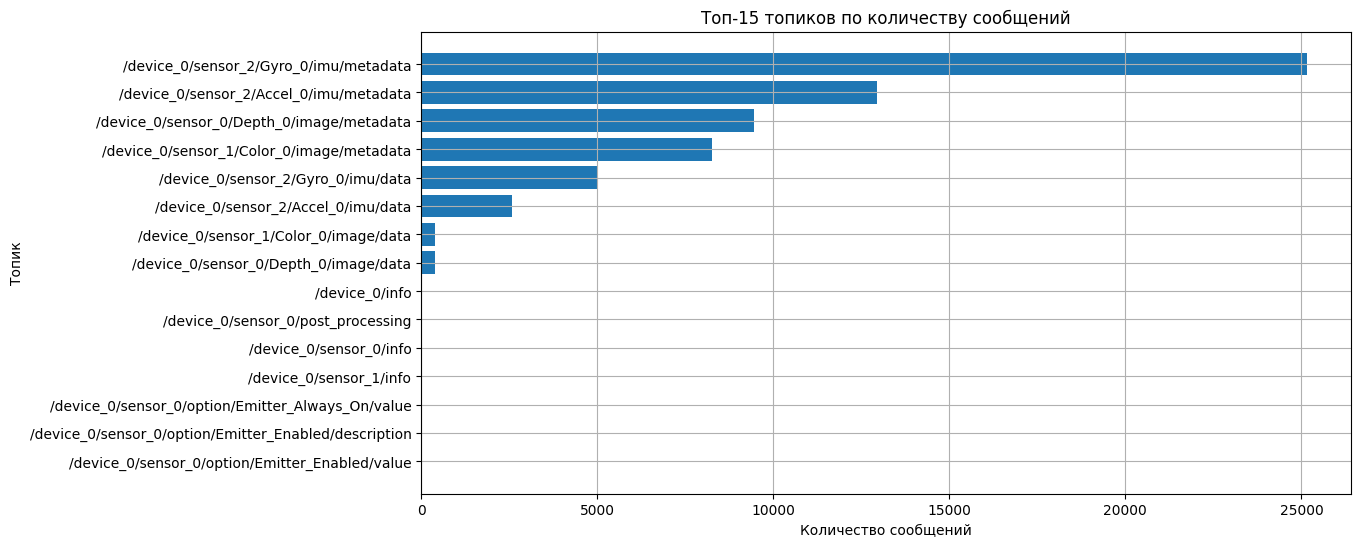

In [33]:
if "Message Count" in topics_df.columns and "Topics" in topics_df.columns:
    plot_df = topics_df.sort_values("Message Count", ascending=False).head(15).copy()
    plt.figure(figsize=(12, 6))
    plt.barh(plot_df["Topics"].astype(str), plot_df["Message Count"])
    plt.gca().invert_yaxis()
    plt.title("Топ-15 топиков по количеству сообщений")
    plt.xlabel("Количество сообщений")
    plt.ylabel("Топик")
    plt.show()

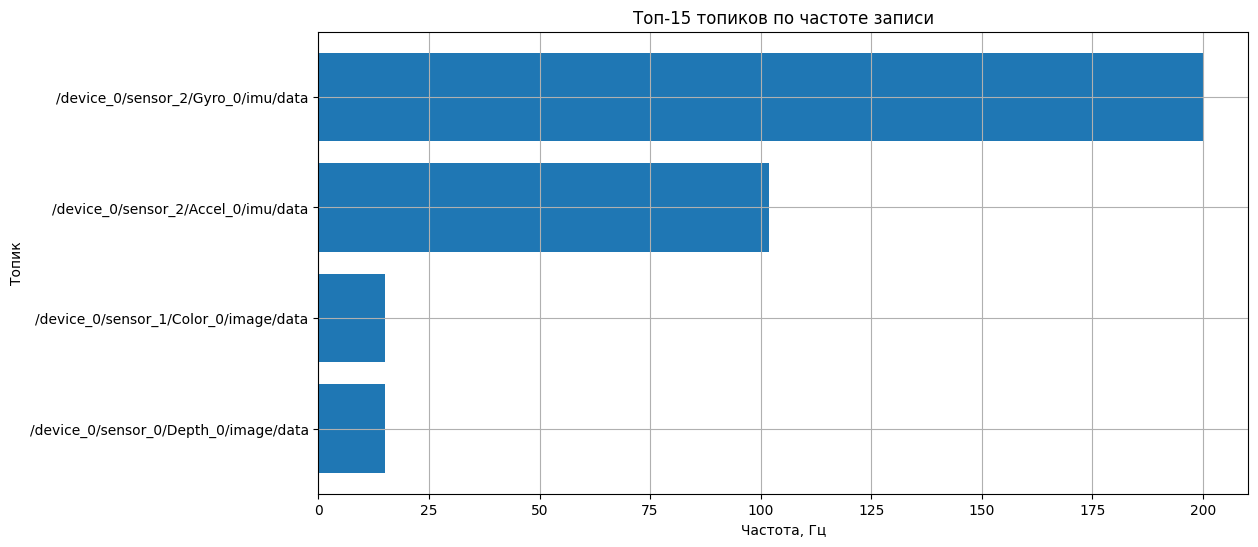

In [34]:
if "Frequency" in topics_df.columns and "Topics" in topics_df.columns:
    freq_df = topics_df.dropna(subset=["Frequency"]).sort_values("Frequency", ascending=False).head(15).copy()
    plt.figure(figsize=(12, 6))
    plt.barh(freq_df["Topics"].astype(str), freq_df["Frequency"])
    plt.gca().invert_yaxis()
    plt.title("Топ-15 топиков по частоте записи")
    plt.xlabel("Частота, Гц")
    plt.ylabel("Топик")
    plt.show()

## 5. Поиск IMU-топиков

Для дальнейшего анализа удобно взять данные инерциальных датчиков: акселерометр и гироскоп.  
Они обычно имеют тип `sensor_msgs/Imu` и содержат поля `linear_acceleration.*` и `angular_velocity.*`.

In [35]:
def filter_topics_by_text(df, text):
    mask = pd.Series(False, index=df.index)
    for col in ["Topics", "Types"]:
        if col in df.columns:
            mask = mask | df[col].astype(str).str.contains(text, case=False, regex=False, na=False)
    return df[mask].copy()

imu_topics = filter_topics_by_text(topics_df, "imu")
imu_topics[display_cols]

,Topics,Types,Message Count,Frequency
89,/device_0/sensor_2/Accel_0/imu/data,sensor_msgs/Imu,2591,101.987200
90,/device_0/sensor_2/Accel_0/imu/metadata,diagnostic_msgs/KeyValue,12955,NaN
91,/device_0/sensor_2/Accel_0/imu_intrinsic,realsense_msgs/ImuIntrinsic,1,NaN
94,/device_0/sensor_2/Gyro_0/imu/data,sensor_msgs/Imu,5031,200.290341
95,/device_0/sensor_2/Gyro_0/imu/metadata,diagnostic_msgs/KeyValue,25155,NaN
96,/device_0/sensor_2/Gyro_0/imu_intrinsic,realsense_msgs/ImuIntrinsic,1,NaN


In [36]:
def choose_topic(df, keyword):
    # Выбирает первый топик, в названии которого есть keyword.
    if "Topics" not in df.columns:
        return None
    matches = df[df["Topics"].astype(str).str.contains(keyword, case=False, regex=False, na=False)]
    if len(matches) == 0:
        return None
    return matches.iloc[0]["Topics"]

accel_topic = choose_topic(imu_topics, "Accel")
gyro_topic = choose_topic(imu_topics, "Gyro")

print("Топик акселерометра:", accel_topic)
print("Топик гироскопа:", gyro_topic)

Топик акселерометра: /device_0/sensor_2/Accel_0/imu/data
Топик гироскопа: /device_0/sensor_2/Gyro_0/imu/data


## 6. Выгрузка выбранных топиков в DataFrame

Метод `message_by_topic()` выгружает выбранный топик в CSV, после чего его можно прочитать через `pandas`.

In [37]:
def read_topic_to_df(reader, topic_name):
    if topic_name is None:
        return None

    csv_path = reader.message_by_topic(topic_name)
    df = pd.read_csv(csv_path)

    # Пробуем привести все возможные числовые колонки к числовому формату.
    for col in df.columns:
        try:
            df[col] = pd.to_numeric(df[col])
        except Exception:
            pass

    return df

accel_df = read_topic_to_df(b, accel_topic)
gyro_df = read_topic_to_df(b, gyro_topic)

print("Размер accel_df:", None if accel_df is None else accel_df.shape)
print("Размер gyro_df:", None if gyro_df is None else gyro_df.shape)

Размер accel_df: (2591, 42)
Размер gyro_df: (5031, 42)


In [38]:
if accel_df is not None:
    display(accel_df.head())

if gyro_df is not None:
    display(gyro_df.head())

,Time,header.seq,header.stamp.secs,header.stamp.nsecs,header.frame_id,orientation.x,orientation.y,orientation.z,orientation.w,orientation_covariance_0,orientation_covariance_1,orientation_covariance_2,orientation_covariance_3,orientation_covariance_4,orientation_covariance_5,orientation_covariance_6,orientation_covariance_7,orientation_covariance_8,angular_velocity.x,angular_velocity.y,angular_velocity.z,angular_velocity_covariance_0,angular_velocity_covariance_1,angular_velocity_covariance_2,angular_velocity_covariance_3,angular_velocity_covariance_4,angular_velocity_covariance_5,angular_velocity_covariance_6,angular_velocity_covariance_7,angular_velocity_covariance_8,linear_acceleration.x,linear_acceleration.y,linear_acceleration.z,linear_acceleration_covariance_0,linear_acceleration_covariance_1,linear_acceleration_covariance_2,linear_acceleration_covariance_3,linear_acceleration_covariance_4,linear_acceleration_covariance_5,linear_acceleration_covariance_6,linear_acceleration_covariance_7,linear_acceleration_covariance_8
0,0.000383,47404,1673969860,238107681,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.108151,-9.659550,-0.107873,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.010330,47405,1673969860,247928381,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.117958,-9.639936,-0.107873,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.020583,47406,1673969860,257749557,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.108151,-9.630130,-0.098066,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.030097,47407,1673969860,267572165,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.098345,-9.620323,-0.107873,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.041590,47408,1673969860,277393103,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.088538,-9.630130,-0.117680,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


,Time,header.seq,header.stamp.secs,header.stamp.nsecs,header.frame_id,orientation.x,orientation.y,orientation.z,orientation.w,orientation_covariance_0,orientation_covariance_1,orientation_covariance_2,orientation_covariance_3,orientation_covariance_4,orientation_covariance_5,orientation_covariance_6,orientation_covariance_7,orientation_covariance_8,angular_velocity.x,angular_velocity.y,angular_velocity.z,angular_velocity_covariance_0,angular_velocity_covariance_1,angular_velocity_covariance_2,angular_velocity_covariance_3,angular_velocity_covariance_4,angular_velocity_covariance_5,angular_velocity_covariance_6,angular_velocity_covariance_7,angular_velocity_covariance_8,linear_acceleration.x,linear_acceleration.y,linear_acceleration.z,linear_acceleration_covariance_0,linear_acceleration_covariance_1,linear_acceleration_covariance_2,linear_acceleration_covariance_3,linear_acceleration_covariance_4,linear_acceleration_covariance_5,linear_acceleration_covariance_6,linear_acceleration_covariance_7,linear_acceleration_covariance_8
0,0.000015,92990,1673969860,237489462,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.001745,0.000000,-0.003491,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.005167,92991,1673969860,242477894,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.003491,0.003491,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.009925,92992,1673969860,247466326,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.001745,0.000000,-0.003491,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.014939,92993,1673969860,252454519,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,-0.001745,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.020369,92994,1673969860,257442951,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 7. Подготовка временной оси и инженерных признаков

Добавим относительное время `t_rel_sec`, а также модуль вектора ускорения и модуль угловой скорости.

In [39]:
def add_time_columns(df):
    df = df.copy()

    if "Time" in df.columns:
        df["t_rel_sec"] = df["Time"] - df["Time"].min()
    elif {"header.stamp.secs", "header.stamp.nsecs"}.issubset(df.columns):
        abs_time = df["header.stamp.secs"] + df["header.stamp.nsecs"] * 1e-9
        df["t_rel_sec"] = abs_time - abs_time.min()
    else:
        df["t_rel_sec"] = np.arange(len(df))

    return df

def add_vector_module(df, columns, result_col):
    df = df.copy()
    existing = [c for c in columns if c in df.columns]
    if len(existing) == 3:
        df[result_col] = np.sqrt(sum(df[c] ** 2 for c in existing))
    return df

if accel_df is not None:
    accel_df = add_time_columns(accel_df)
    accel_df = add_vector_module(
        accel_df,
        ["linear_acceleration.x", "linear_acceleration.y", "linear_acceleration.z"],
        "linear_acceleration_module"
    )

if gyro_df is not None:
    gyro_df = add_time_columns(gyro_df)
    gyro_df = add_vector_module(
        gyro_df,
        ["angular_velocity.x", "angular_velocity.y", "angular_velocity.z"],
        "angular_velocity_module"
    )

display(accel_df.head() if accel_df is not None else "Нет данных акселерометра")
display(gyro_df.head() if gyro_df is not None else "Нет данных гироскопа")

,Time,header.seq,header.stamp.secs,header.stamp.nsecs,header.frame_id,orientation.x,orientation.y,orientation.z,orientation.w,orientation_covariance_0,orientation_covariance_1,orientation_covariance_2,orientation_covariance_3,orientation_covariance_4,orientation_covariance_5,orientation_covariance_6,orientation_covariance_7,orientation_covariance_8,angular_velocity.x,angular_velocity.y,angular_velocity.z,angular_velocity_covariance_0,angular_velocity_covariance_1,angular_velocity_covariance_2,angular_velocity_covariance_3,angular_velocity_covariance_4,angular_velocity_covariance_5,angular_velocity_covariance_6,angular_velocity_covariance_7,angular_velocity_covariance_8,linear_acceleration.x,linear_acceleration.y,linear_acceleration.z,linear_acceleration_covariance_0,linear_acceleration_covariance_1,linear_acceleration_covariance_2,linear_acceleration_covariance_3,linear_acceleration_covariance_4,linear_acceleration_covariance_5,linear_acceleration_covariance_6,linear_acceleration_covariance_7,linear_acceleration_covariance_8,t_rel_sec,linear_acceleration_module
0,0.000383,47404,1673969860,238107681,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.108151,-9.659550,-0.107873,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,9.723504
1,0.010330,47405,1673969860,247928381,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.117958,-9.639936,-0.107873,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.009947,9.705145
2,0.020583,47406,1673969860,257749557,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.108151,-9.630130,-0.098066,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.020201,9.694174
3,0.030097,47407,1673969860,267572165,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.098345,-9.620323,-0.107873,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.029715,9.683420
4,0.041590,47408,1673969860,277393103,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.088538,-9.630130,-0.117680,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.041207,9.692170


,Time,header.seq,header.stamp.secs,header.stamp.nsecs,header.frame_id,orientation.x,orientation.y,orientation.z,orientation.w,orientation_covariance_0,orientation_covariance_1,orientation_covariance_2,orientation_covariance_3,orientation_covariance_4,orientation_covariance_5,orientation_covariance_6,orientation_covariance_7,orientation_covariance_8,angular_velocity.x,angular_velocity.y,angular_velocity.z,angular_velocity_covariance_0,angular_velocity_covariance_1,angular_velocity_covariance_2,angular_velocity_covariance_3,angular_velocity_covariance_4,angular_velocity_covariance_5,angular_velocity_covariance_6,angular_velocity_covariance_7,angular_velocity_covariance_8,linear_acceleration.x,linear_acceleration.y,linear_acceleration.z,linear_acceleration_covariance_0,linear_acceleration_covariance_1,linear_acceleration_covariance_2,linear_acceleration_covariance_3,linear_acceleration_covariance_4,linear_acceleration_covariance_5,linear_acceleration_covariance_6,linear_acceleration_covariance_7,linear_acceleration_covariance_8,t_rel_sec,angular_velocity_module
0,0.000015,92990,1673969860,237489462,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.001745,0.000000,-0.003491,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.003903
1,0.005167,92991,1673969860,242477894,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.003491,0.003491,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.005152,0.004937
2,0.009925,92992,1673969860,247466326,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.001745,0.000000,-0.003491,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.009910,0.003903
3,0.014939,92993,1673969860,252454519,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,-0.001745,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.014924,0.001745
4,0.020369,92994,1673969860,257442951,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.020354,0.000000


In [40]:
def estimate_frequency(df):
    if df is None or "t_rel_sec" not in df.columns or len(df) < 2:
        return np.nan
    dt = df["t_rel_sec"].diff().dropna()
    dt = dt[dt > 0]
    if len(dt) == 0:
        return np.nan
    return 1 / dt.median()

accel_freq = estimate_frequency(accel_df)
gyro_freq = estimate_frequency(gyro_df)

pd.DataFrame({
    "sensor": ["accelerometer", "gyroscope"],
    "topic": [accel_topic, gyro_topic],
    "rows": [None if accel_df is None else len(accel_df), None if gyro_df is None else len(gyro_df)],
    "estimated_frequency_hz": [accel_freq, gyro_freq]
})

,sensor,topic,rows,estimated_frequency_hz
0,accelerometer,/device_0/sensor_2/Accel_0/imu/data,2591,101.987200
1,gyroscope,/device_0/sensor_2/Gyro_0/imu/data,5031,200.290341


## 8. Первичный EDA по данным датчиков

Проверим пропуски, дубликаты и базовые статистики.

In [41]:
def basic_quality_report(df, name):
    if df is None:
        return pd.DataFrame({"dataset": [name], "status": ["нет данных"]})

    return pd.DataFrame({
        "dataset": [name],
        "rows": [len(df)],
        "columns": [df.shape[1]],
        "duplicated_rows": [df.duplicated().sum()],
        "missing_values_total": [df.isna().sum().sum()]
    })

quality_report = pd.concat([
    basic_quality_report(accel_df, "accelerometer"),
    basic_quality_report(gyro_df, "gyroscope")
], ignore_index=True)

quality_report

,dataset,rows,columns,duplicated_rows,missing_values_total
0,accelerometer,2591,44,0,0
1,gyroscope,5031,44,0,0


In [42]:
def numeric_stats(df, cols, name):
    if df is None:
        return pd.DataFrame()
    cols = [c for c in cols if c in df.columns]
    if not cols:
        return pd.DataFrame()

    stats = df[cols].describe().T
    stats.insert(0, "dataset", name)
    return stats

accel_cols = [
    "linear_acceleration.x",
    "linear_acceleration.y",
    "linear_acceleration.z",
    "linear_acceleration_module"
]

gyro_cols = [
    "angular_velocity.x",
    "angular_velocity.y",
    "angular_velocity.z",
    "angular_velocity_module"
]

stats_df = pd.concat([
    numeric_stats(accel_df, accel_cols, "accelerometer"),
    numeric_stats(gyro_df, gyro_cols, "gyroscope")
])

stats_df

,dataset,count,mean,std,min,25%,50%,75%,max
linear_acceleration.x,accelerometer,2591.0,-1.103810,0.009248,-1.137571,-1.108151,-1.108151,-1.098345,-1.068925
linear_acceleration.y,accelerometer,2591.0,-9.632465,0.014512,-9.688970,-9.639936,-9.630130,-9.620323,-9.581097
linear_acceleration.z,accelerometer,2591.0,-0.111200,0.008819,-0.137293,-0.117680,-0.107873,-0.107873,-0.078453
linear_acceleration_module,accelerometer,2591.0,9.696149,0.014479,9.644450,9.684537,9.694393,9.704134,9.751735
angular_velocity.x,gyroscope,5031.0,-0.003183,0.002836,-0.013963,-0.005236,-0.003491,0.000000,0.005236
angular_velocity.y,gyroscope,5031.0,0.001752,0.002462,-0.006981,0.000000,0.001745,0.003491,0.012217
angular_velocity.z,gyroscope,5031.0,-0.001137,0.001655,-0.008727,-0.001745,0.000000,0.000000,0.005236
angular_velocity_module,gyroscope,5031.0,0.005003,0.002511,0.000000,0.003491,0.005236,0.006530,0.015115


## 9. Визуализация временных рядов

Построим графики по осям X/Y/Z и модулю вектора.

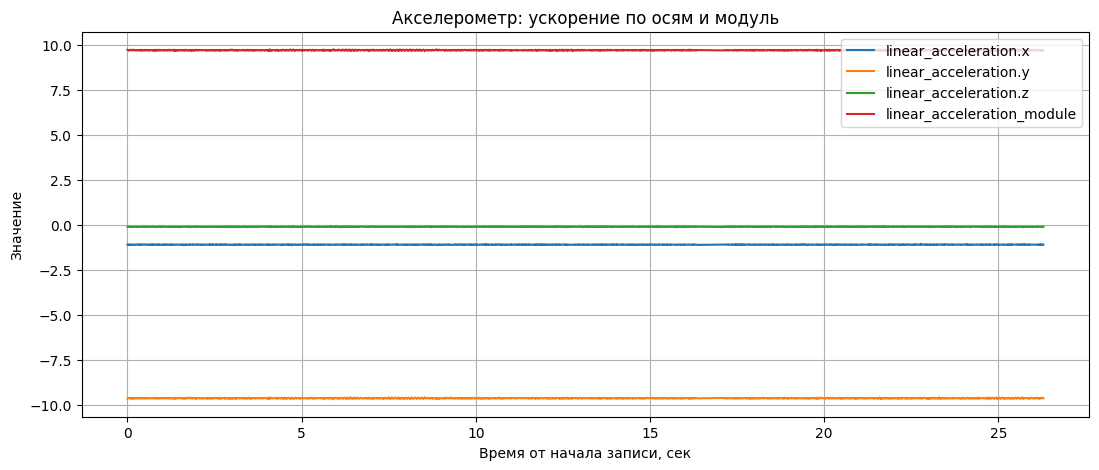

Гироскоп: угловая скорость по осям и модуль: для графика взята каждая 1-я строка


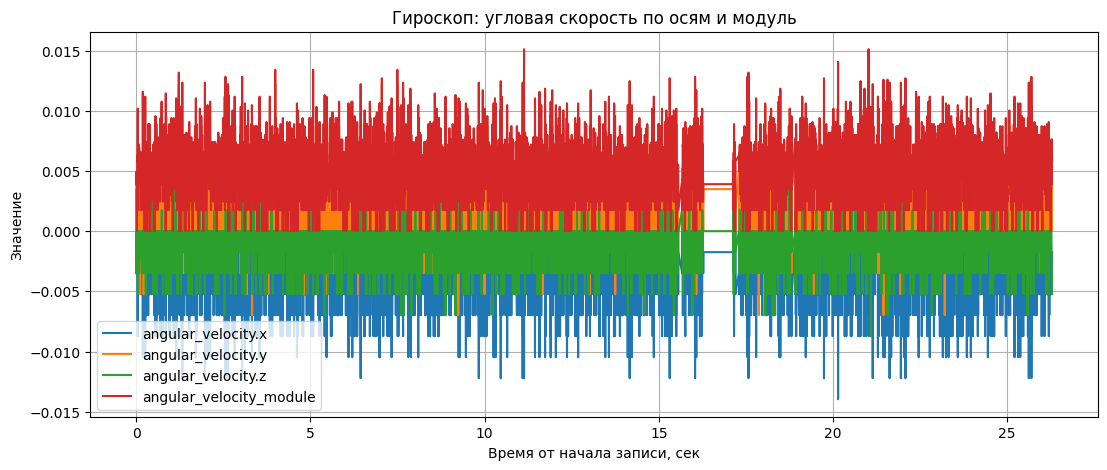

In [43]:
def plot_time_series(df, cols, title, max_points=5000):
    if df is None:
        print(f"{title}: нет данных")
        return

    cols = [c for c in cols if c in df.columns]
    if not cols:
        print(f"{title}: нужные колонки не найдены")
        return

    plot_df = df.copy()
    if len(plot_df) > max_points:
        step = max(1, len(plot_df) // max_points)
        plot_df = plot_df.iloc[::step].copy()
        print(f"{title}: для графика взята каждая {step}-я строка")

    plt.figure(figsize=(13, 5))
    for col in cols:
        plt.plot(plot_df["t_rel_sec"], plot_df[col], label=col)
    plt.title(title)
    plt.xlabel("Время от начала записи, сек")
    plt.ylabel("Значение")
    plt.legend()
    plt.show()

plot_time_series(
    accel_df,
    ["linear_acceleration.x", "linear_acceleration.y", "linear_acceleration.z", "linear_acceleration_module"],
    "Акселерометр: ускорение по осям и модуль"
)

plot_time_series(
    gyro_df,
    ["angular_velocity.x", "angular_velocity.y", "angular_velocity.z", "angular_velocity_module"],
    "Гироскоп: угловая скорость по осям и модуль"
)

## 10. Скользящие средние

Скользящее среднее помогает увидеть общий тренд и сгладить шум.

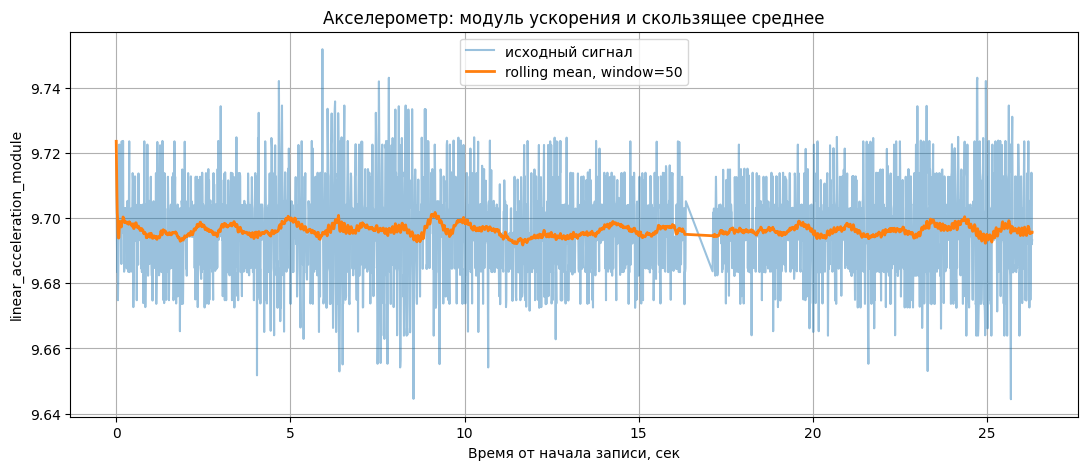

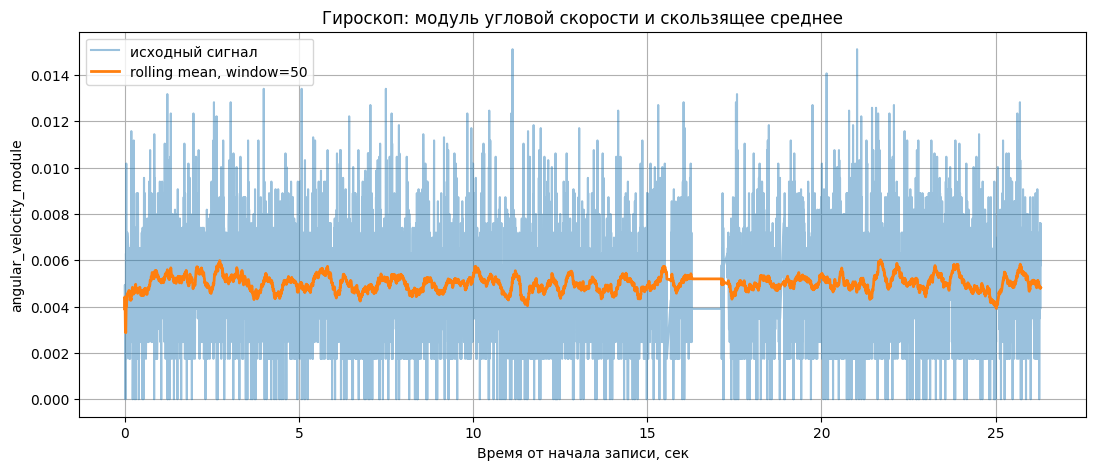

In [44]:
def plot_rolling_mean(df, value_col, title, window=50):
    if df is None or value_col not in df.columns:
        print(f"{title}: колонка {value_col!r} не найдена")
        return

    plot_df = df[["t_rel_sec", value_col]].copy()
    plot_df[f"{value_col}_rolling_mean"] = plot_df[value_col].rolling(window=window, min_periods=1).mean()

    if len(plot_df) > 5000:
        step = max(1, len(plot_df) // 5000)
        plot_df = plot_df.iloc[::step]

    plt.figure(figsize=(13, 5))
    plt.plot(plot_df["t_rel_sec"], plot_df[value_col], alpha=0.45, label="исходный сигнал")
    plt.plot(plot_df["t_rel_sec"], plot_df[f"{value_col}_rolling_mean"], linewidth=2, label=f"rolling mean, window={window}")
    plt.title(title)
    plt.xlabel("Время от начала записи, сек")
    plt.ylabel(value_col)
    plt.legend()
    plt.show()

plot_rolling_mean(accel_df, "linear_acceleration_module", "Акселерометр: модуль ускорения и скользящее среднее")
plot_rolling_mean(gyro_df, "angular_velocity_module", "Гироскоп: модуль угловой скорости и скользящее среднее")

## 11. Распределение значений

Гистограммы позволяют быстро увидеть разброс значений и наличие выбросов.

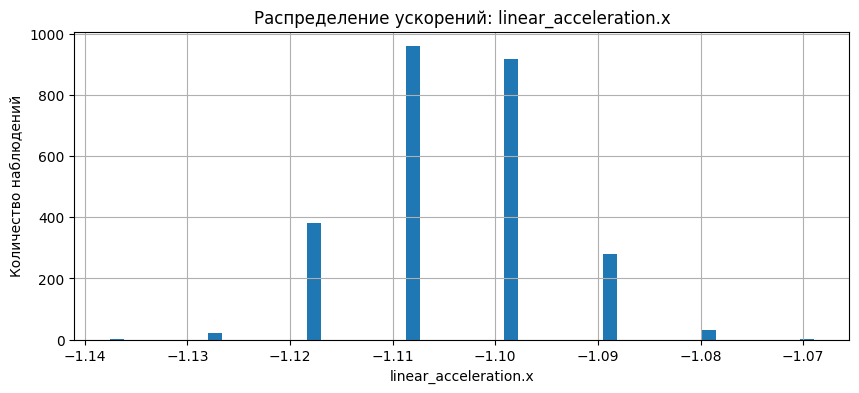

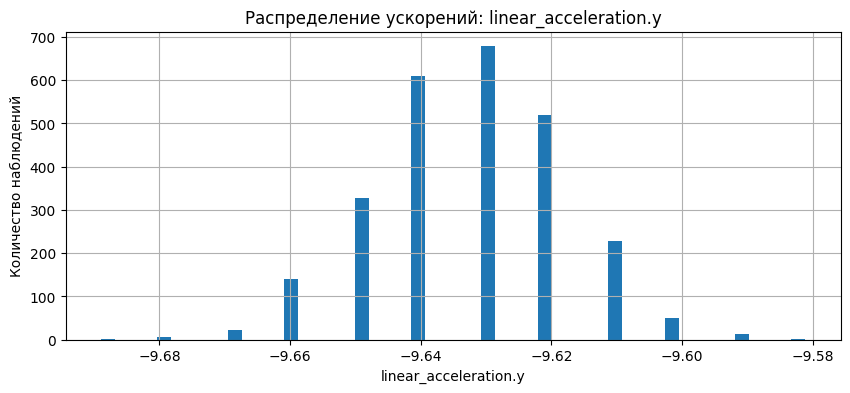

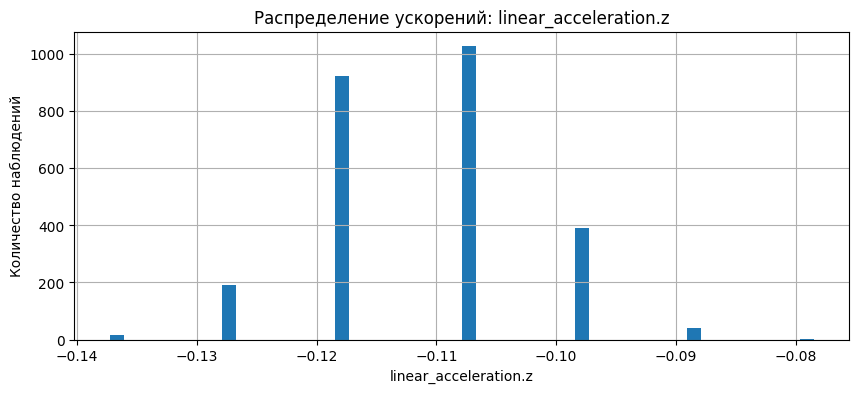

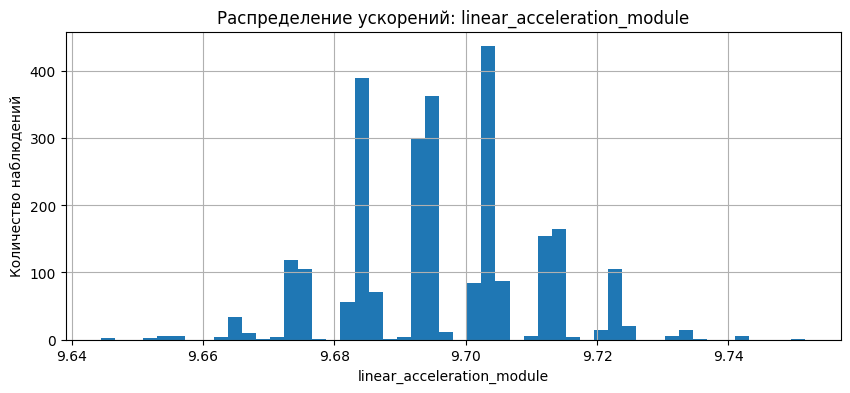

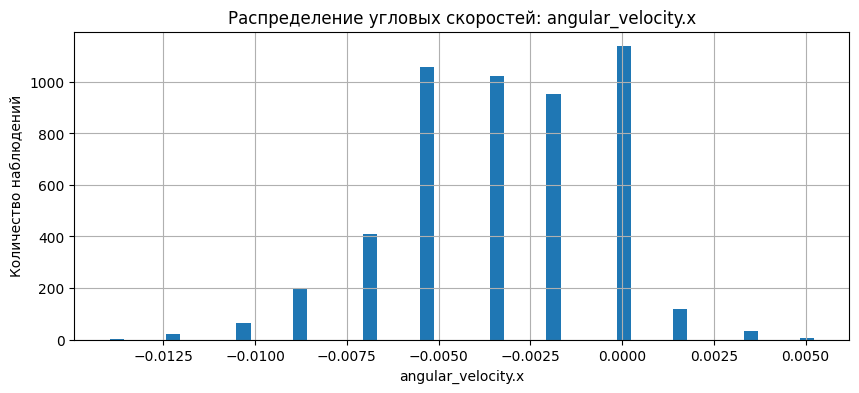

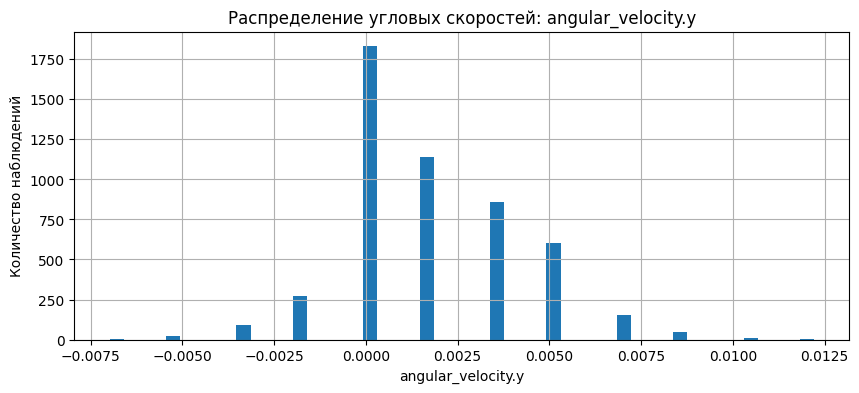

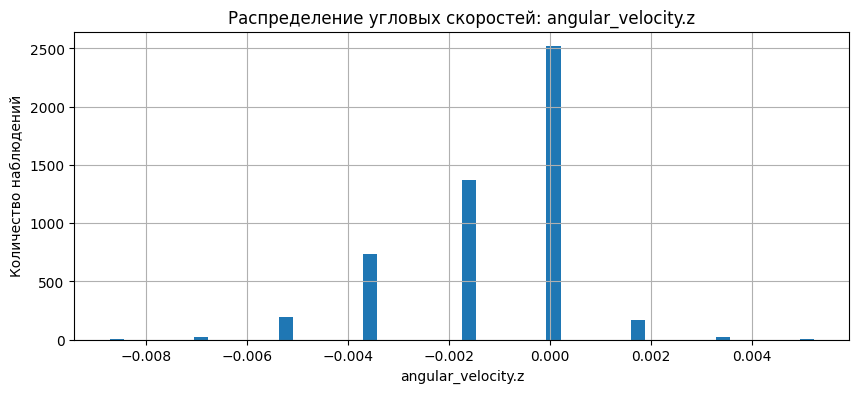

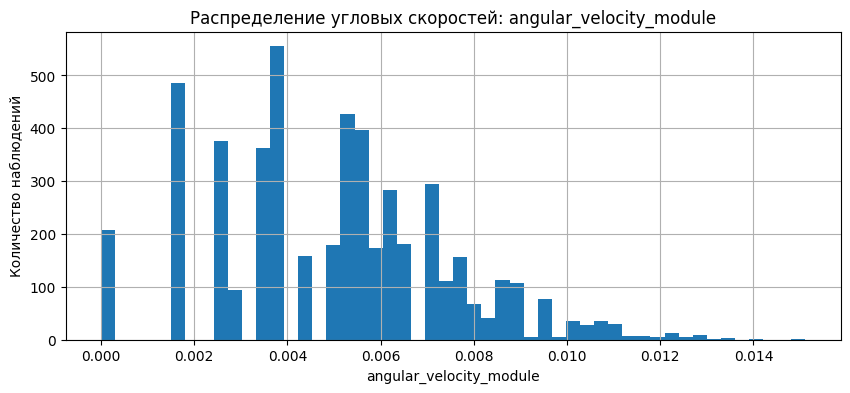

In [45]:
def plot_histogram(df, cols, title):
    if df is None:
        print(f"{title}: нет данных")
        return

    cols = [c for c in cols if c in df.columns]
    if not cols:
        print(f"{title}: нужные колонки не найдены")
        return

    for col in cols:
        plt.figure(figsize=(10, 4))
        plt.hist(df[col].dropna(), bins=50)
        plt.title(f"{title}: {col}")
        plt.xlabel(col)
        plt.ylabel("Количество наблюдений")
        plt.show()

plot_histogram(accel_df, ["linear_acceleration.x", "linear_acceleration.y", "linear_acceleration.z", "linear_acceleration_module"], "Распределение ускорений")
plot_histogram(gyro_df, ["angular_velocity.x", "angular_velocity.y", "angular_velocity.z", "angular_velocity_module"], "Распределение угловых скоростей")

## 12. Корреляция между осями

Посмотрим, насколько связаны между собой измерения по разным осям.

,linear_acceleration.x,linear_acceleration.y,linear_acceleration.z,linear_acceleration_module
linear_acceleration.x,1.000000,0.021895,-0.008139,-0.094450
linear_acceleration.y,0.021895,1.000000,-0.001833,-0.997334
linear_acceleration.z,-0.008139,-0.001833,1.000000,-0.004558
linear_acceleration_module,-0.094450,-0.997334,-0.004558,1.000000


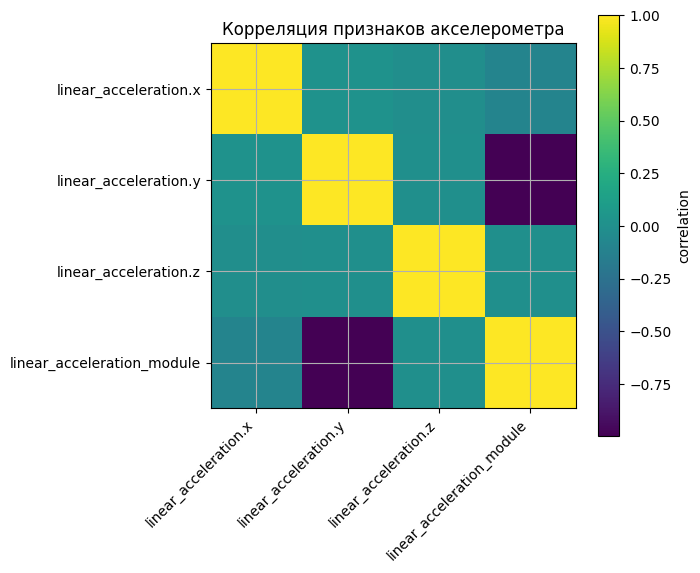

,angular_velocity.x,angular_velocity.y,angular_velocity.z,angular_velocity_module
angular_velocity.x,1.000000,0.070455,0.077150,-0.739890
angular_velocity.y,0.070455,1.000000,-0.121118,0.387704
angular_velocity.z,0.077150,-0.121118,1.000000,-0.327979
angular_velocity_module,-0.739890,0.387704,-0.327979,1.000000


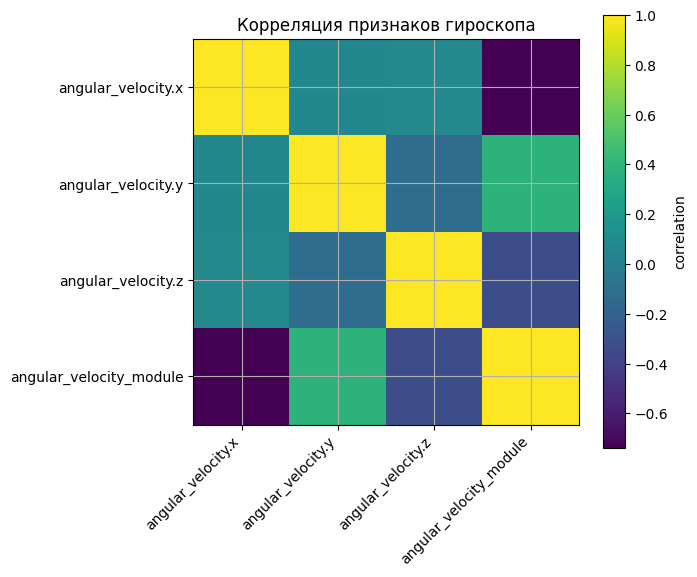

In [46]:
def plot_correlation_matrix(df, cols, title):
    if df is None:
        print(f"{title}: нет данных")
        return

    cols = [c for c in cols if c in df.columns]
    if len(cols) < 2:
        print(f"{title}: мало колонок для корреляции")
        return

    corr = df[cols].corr()
    display(corr)

    plt.figure(figsize=(7, 6))
    plt.imshow(corr, interpolation="nearest")
    plt.colorbar(label="correlation")
    plt.xticks(range(len(cols)), cols, rotation=45, ha="right")
    plt.yticks(range(len(cols)), cols)
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_correlation_matrix(
    accel_df,
    ["linear_acceleration.x", "linear_acceleration.y", "linear_acceleration.z", "linear_acceleration_module"],
    "Корреляция признаков акселерометра"
)

plot_correlation_matrix(
    gyro_df,
    ["angular_velocity.x", "angular_velocity.y", "angular_velocity.z", "angular_velocity_module"],
    "Корреляция признаков гироскопа"
)

## 13. Объединение акселерометра и гироскопа

Так как частота записи у датчиков может отличаться, используем `merge_asof`: ближайшее значение гироскопа сопоставляется с измерением акселерометра по времени.

In [47]:
merged_imu_df = None

if accel_df is not None and gyro_df is not None:
    left = accel_df.sort_values("t_rel_sec").copy()
    right = gyro_df.sort_values("t_rel_sec").copy()

    # Оставим только наиболее полезные колонки, чтобы результат не был слишком широким.
    left_cols = ["t_rel_sec"] + [c for c in accel_cols if c in left.columns]
    right_cols = ["t_rel_sec"] + [c for c in gyro_cols if c in right.columns]

    merged_imu_df = pd.merge_asof(
        left[left_cols],
        right[right_cols],
        on="t_rel_sec",
        direction="nearest",
        tolerance=0.02
    )

    display(merged_imu_df.head())
    print("Размер merged_imu_df:", merged_imu_df.shape)
else:
    print("Для объединения нужны и accel_df, и gyro_df.")

,t_rel_sec,linear_acceleration.x,linear_acceleration.y,linear_acceleration.z,linear_acceleration_module,angular_velocity.x,angular_velocity.y,angular_velocity.z,angular_velocity_module
0,0.000000,-1.108151,-9.659550,-0.107873,9.723504,-0.001745,0.000000,-0.003491,0.003903
1,0.009947,-1.117958,-9.639936,-0.107873,9.705145,-0.001745,0.000000,-0.003491,0.003903
2,0.020201,-1.108151,-9.630130,-0.098066,9.694174,0.000000,0.000000,0.000000,0.000000
3,0.029715,-1.098345,-9.620323,-0.107873,9.683420,0.000000,0.000000,-0.001745,0.001745
4,0.041207,-1.088538,-9.630130,-0.117680,9.692170,-0.005236,0.001745,-0.001745,0.005789


Размер merged_imu_df: (2591, 9)


In [48]:
if merged_imu_df is not None:
    merged_imu_df.to_csv("merged_imu_data.csv", index=False)
    print("Файл merged_imu_data.csv сохранён")

if accel_df is not None:
    accel_df.to_csv("accelerometer_data.csv", index=False)
    print("Файл accelerometer_data.csv сохранён")

if gyro_df is not None:
    gyro_df.to_csv("gyroscope_data.csv", index=False)
    print("Файл gyroscope_data.csv сохранён")

Файл merged_imu_data.csv сохранён
Файл accelerometer_data.csv сохранён
Файл gyroscope_data.csv сохранён


## 14. Итоговые выводы

В ходе работы был прочитан файл формата `.bag`, получена таблица доступных ROS-топиков и выполнен анализ временных рядов IMU-датчиков.

Основные результаты:
1. Таблица топиков позволяет быстро понять состав bag-файла: типы сообщений, количество записей и частоты.
2. Для анализа были выбраны IMU-топики акселерометра и гироскопа.
3. Данные из топиков были выгружены в CSV и прочитаны как `Pandas DataFrame`.
4. Для каждого датчика построены временные графики по осям X/Y/Z и рассчитан модуль вектора.
5. Были выполнены проверки качества данных: размерность, пропуски, дубликаты, базовая статистика.
6. Построены гистограммы, скользящие средние и матрицы корреляций.
7. Данные акселерометра и гироскопа объединены в общий датасет по ближайшему времени наблюдения.

Таким образом, `bagpy` позволяет использовать ROS bag-файлы как обычный источник данных для анализа в Python: сначала топики выгружаются в CSV, после чего с ними можно работать средствами `pandas`, `numpy` и `matplotlib`.